In [2]:
pip install numpy scipy matplotlib plotly

In [3]:
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# Scipy.stats
from scipy.stats import norm

# Random Generator
rng = np.random.default_rng(123)

import time
import datetime as dt

In [4]:
def MC_options_is(S, K, T, r, sigma, N, option_type='call', is_shift=True):
    """
    Monte Carlo simulation for European options with importance sampling
    """
    if is_shift:
      mu_shift = (np.log(K) - np.log(S) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    else:
      mu_shift = 0

    X = rng.normal(mu_shift, 1, N)

    # Calculate stock prices at expiration
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)

    # Calculate discounted payoffs
    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(ST - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - ST, 0)

    weight = np.exp(-mu_shift * X + 0.5 * mu_shift**2)
    payoffs *= weight

    # Calculate price and variance
    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance

In [5]:
def MC_asian_options_is(S, K, T, r, sigma, N, n_steps=252, option_type='call', avg_type='arithmetic'):
    """
    Asian options with importance sampling
    """
    dt = T / n_steps

    # Importance sampling: shift the distribution toward the average being near K
    # We approximate by shifting the final distribution
    mu_shift = (np.log(K) - np.log(S) - (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    Z = rng.normal(mu_shift / n_steps, 1, (N, n_steps))  # Distribute shift across steps

    # Simulate price paths
    prices = np.zeros((N, n_steps + 1))
    prices[:, 0] = S

    for t in range(1, n_steps + 1):
        prices[:, t] = prices[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

    # Calculate average price
    if avg_type == 'arithmetic':
        avg_price = np.mean(prices[:, 1:], axis=1)
    else:  # geometric
        avg_price = np.exp(np.mean(np.log(prices[:, 1:]), axis=1))

    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(avg_price - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - avg_price, 0)

    # Importance sampling weight (cumulative across all steps)
    total_shift = mu_shift / n_steps
    weights = np.exp(-total_shift * np.sum(Z, axis=1) + 0.5 * total_shift**2 * n_steps)
    payoffs *= weights

    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance, prices

In [6]:
#Testcase1: Hardcode
S = 60
K_call = 65
K_put = 55
T = 1.0
r = 0.03
sigma_call = 0.3
sigma_put = 0.3



Comparing the options for different strike prices (N=1000000)


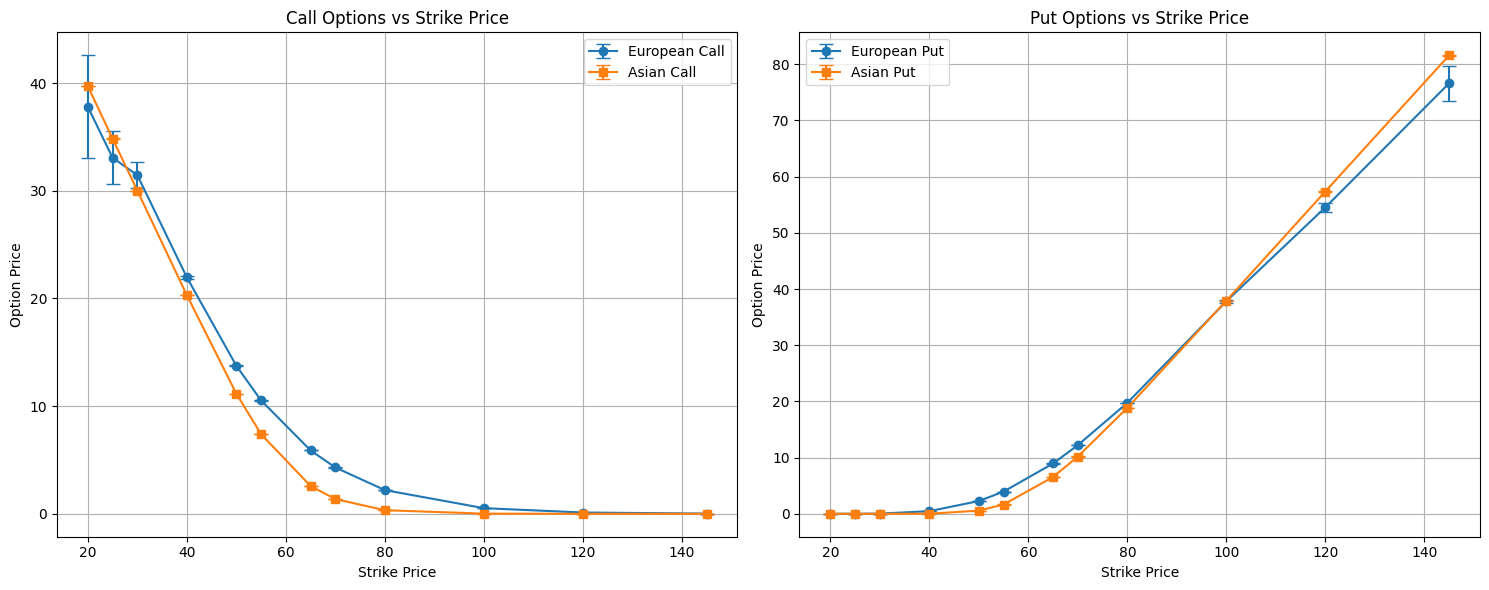


Option Price Analysis Summary:
Strike	European Call	European Time Put	Asian Time Call	Asian Put Time
20.00	37.806364	0.14	0.000203	0.09	39.718072		31.05	0.000000		31.77
25.00	33.070892	0.10	0.004068	0.17	34.848106		28.15	0.000000		26.90
30.00	31.459515	0.06	0.032671	0.06	30.015585		25.45	0.000006		25.79
40.00	21.964833	0.07	0.468771	0.06	20.311709		25.89	0.014973		26.58
50.00	13.751681	0.06	2.268194	0.06	11.157138		25.70	0.559184		26.67
55.00	10.529111	0.06	3.953283	0.06	7.399273		26.13	1.652873		27.57
65.00	5.888118	0.09	8.953962	0.09	2.577242		25.87	6.548152		26.37
70.00	4.300961	0.06	12.219236	0.06	1.369270		25.83	10.188763		26.53
80.00	2.201429	0.06	19.746909	0.06	0.334345		26.03	18.858432		25.82
100.00	0.524596	0.06	37.823797	0.06	0.014305		25.94	37.926082		26.54
120.00	0.117773	0.06	54.535290	0.06	0.000366		25.81	57.359331		26.17
145.00	0.018080	0.07	76.611296	0.06	0.000006		27.22	81.581320		34.11

SEM Analysis Summary:
Strike	European Call	European Time Put	Asian Time Call	Asia

In [8]:
# Compare Monte Carlo estimates for different strike prices (including Asian options)
strike_prices = [20,25,30,40,50,55,65,70,80,100,120,145]
N_fixed = 10**6

print(f"\n\nComparing the options for different strike prices (N={N_fixed})")

european_call_prices = []
european_put_prices = []
asian_call_prices = []
asian_put_prices = []

european_call_errors = []
european_put_errors = []
asian_call_errors = []
asian_put_errors = []

european_call_perrors = []
european_put_perrors = []
asian_call_perrors = []
asian_put_perrors = []

european_call_times = []
european_put_times = []
asian_call_times = []
asian_put_times = []
total_times = []

for K in strike_prices:
    total_time_per_strike = 0

    # European Call option
    start_time = time.time()
    MC_call_price, var_call = MC_options_is(S, K, T, r, sigma_call, N_fixed, 'call', True)
    call_time = time.time() - start_time
    total_time_per_strike += call_time
    european_call_times.append(call_time)

    SEM_call = np.sqrt(var_call) / np.sqrt(N_fixed)
    european_call_prices.append(MC_call_price)
    european_call_errors.append(SEM_call)
    european_call_perrors.append(SEM_call/MC_call_price if MC_call_price > 1e-10 else 0)

    # European Put option
    start_time = time.time()
    MC_put_price, var_put = MC_options_is(S, K, T, r, sigma_put, N_fixed, 'put', True)
    put_time = time.time() - start_time
    total_time_per_strike += put_time
    european_put_times.append(put_time)

    SEM_put = np.sqrt(var_put) / np.sqrt(N_fixed)
    european_put_prices.append(MC_put_price)
    european_put_errors.append(SEM_put)
    european_put_perrors.append(SEM_put/MC_put_price if MC_put_price > 1e-10 else 0)

    # Asian Call option
    start_time = time.time()
    asian_call_price, var_asian_call, _ = MC_asian_options_is(S, K, T, r, sigma_call, N_fixed, n_steps=252, option_type='call', avg_type='arithmetic')
    asian_call_time = time.time() - start_time
    total_time_per_strike += asian_call_time
    asian_call_times.append(asian_call_time)

    SEM_asian_call = np.sqrt(var_asian_call) / np.sqrt(N_fixed)
    asian_call_prices.append(asian_call_price)
    asian_call_errors.append(SEM_asian_call)
    asian_call_perrors.append(SEM_asian_call/asian_call_price if asian_call_price > 1e-10 else 0)

    # Asian Put option
    start_time = time.time()
    asian_put_price, var_asian_put, _ = MC_asian_options_is(S, K, T, r, sigma_put, N_fixed, n_steps=252, option_type='put', avg_type='arithmetic')
    asian_put_time = time.time() - start_time
    total_time_per_strike += asian_put_time
    asian_put_times.append(asian_put_time)

    SEM_asian_put = np.sqrt(var_asian_put) / np.sqrt(N_fixed)
    asian_put_prices.append(asian_put_price)
    asian_put_errors.append(SEM_asian_put)
    asian_put_perrors.append(SEM_asian_put/asian_put_price if asian_put_price > 1e-10 else 0)

    total_times.append(total_time_per_strike)

# Plotting strike price comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Call options comparison
axes[0].errorbar(strike_prices, european_call_prices, yerr=european_call_errors,
                fmt='o-', label='European Call', capsize=5)
axes[0].errorbar(strike_prices, asian_call_prices, yerr=asian_call_errors,
                fmt='s-', label='Asian Call', capsize=5)
axes[0].set_xlabel('Strike Price')
axes[0].set_ylabel('Option Price')
axes[0].set_title('Call Options vs Strike Price')
axes[0].legend()
axes[0].grid(True)

# Put options comparison
axes[1].errorbar(strike_prices, european_put_prices, yerr=european_put_errors,
                fmt='o-', label='European Put', capsize=5)
axes[1].errorbar(strike_prices, asian_put_prices, yerr=asian_put_errors,
                fmt='s-', label='Asian Put', capsize=5)
axes[1].set_xlabel('Strike Price')
axes[1].set_ylabel('Option Price')
axes[1].set_title('Put Options vs Strike Price')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nOption Price Analysis Summary:")
print("Strike\tEuropean Call\tEuropean Time Put\tAsian Time Call\tAsian Put Time")
for i, K in enumerate(strike_prices):
    print(f"{K:.2f}\t{european_call_prices[i]:.6f}\t{european_call_times[i]:.2f}\t"
          f"{european_put_prices[i]:.6f}\t{european_put_times[i]:.2f}\t"
          f"{asian_call_prices[i]:.6f}\t\t{asian_call_times[i]:.2f}\t"
          f"{asian_put_prices[i]:.6f}\t\t{asian_put_times[i]:.2f}")

print("\nSEM Analysis Summary:")
print("Strike\tEuropean Call\tEuropean Time Put\tAsian Time Call\tAsian Put Time")
for i, K in enumerate(strike_prices):
    print(f"{K:.2f}\t{european_call_errors[i]:.6f}\t{european_call_times[i]:.2f}\t"
          f"{european_put_errors[i]:.6f}\t{european_put_times[i]:.2f}\t"
          f"{asian_call_errors[i]:.6f}\t{asian_call_times[i]:.2f}\t"
          f"{asian_put_errors[i]:.6f}\t{asian_put_times[i]:.2f}")

print("\nPercentage Error Analysis Summary:")
print("Strike\tEuropean Call\tEuropean Time Put\tAsian Time Call\tAsian Put Time")
for i, K in enumerate(strike_prices):
    print(f"{K:.2f}\t{european_call_perrors[i]:.6f}\t{european_call_times[i]:.2f}\t"
          f"{european_put_perrors[i]:.6f}\t{european_put_times[i]:.2f}\t"
          f"{asian_call_perrors[i]:.6f}\t{asian_call_times[i]:.2f}\t"
          f"{asian_put_perrors[i]:.6f}\t{asian_put_times[i]:.2f}")
